# Домашнее задание: Visual Question Answering (VQA)

## 1. Введение

### Что такое VQA?

**Visual Question Answering (VQA)** — задача, в которой модель должна ответить на текстовый вопрос об изображении. Например:
- Изображение: фотография кота
- Вопрос: "Какого цвета кот?"
- Ответ: "Рыжий"

Это мультимодальная задача, требующая понимания как визуальной, так и текстовой информации

### Зачем нужны мультимодальные модели?

Традиционные модели работают либо с изображениями, либо с текстом. Мультимодальные модели объединяют оба типа данных:
- **Простой подход:** объединение эмбеддингов из разных моделей (ResNet + T5)
- **Продвинутый подход:** сквозное обучение (CLIP, LLaVA)

## 2. Подготовка окружения

Установим необходимые библиотеки для работы с моделями и интерфейсами.

In [2]:
!pip install -q torch torchvision transformers open_clip_torch gradio pillow pandas accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [3]:
import torch
import torchvision
from torchvision import transforms, models
from transformers import T5EncoderModel, T5Tokenizer, CLIPProcessor, CLIPModel
from transformers import AutoProcessor, LlavaForConditionalGeneration
import open_clip
import gradio as gr
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch import nn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Используемое устройство: cuda
   GPU: Tesla T4
   Память: 15.83 GB


## 3. Подготовка данных

Создадим небольшой датасет для тестирования. Для простоты возьмем несколько изображений из CIFAR-10 и составим вопросы вручную

### Задание 3.1: Загрузите датасет CIFAR-10

**Что нужно сделать:**
- Загрузите тестовую часть CIFAR-10 (используйте `torchvision.datasets.CIFAR10`)
- Выберите 5-7 изображений из разных классов
- Сохраните их в список `sample_images`

In [4]:
cifar_dataset = torchvision.datasets.CIFAR10(root='./datasets/cifar10', download=True)  # Ваш код здесь

100%|██████████| 170M/170M [00:05<00:00, 30.7MB/s]


In [5]:
sample_images = []    # Список PIL изображений
sample_labels = []    # Список меток классов

# Имена классов CIFAR-10
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

# Маппинг английских названий на русские
cifar_mapping = {
    'airplane': 'самолет',
    'automobile': 'автомобиль',
    'bird': 'птица',
    'cat': 'кот',
    'deer': 'олень',
    'dog': 'собака',
    'frog': 'лягушка',
    'horse': 'лошадь',
    'ship': 'корабль',
    'truck': 'грузовик'
}

# Ваш код здесь: выберите по одному изображению из разных классов

In [6]:
from random import randint

In [7]:
quantity_borders = [randint(5, 7) for _ in range(len(cifar_classes))]

counter = dict()
c_completed_classes = 0
for sample in cifar_dataset:

  border = quantity_borders[sample[1]]
  if sample[1] not in counter:
    counter[sample[1]] = 0

  # add sample if not enought
  if counter[sample[1]] < border:
    sample_images.append(sample[0])
    sample_labels.append(sample[1])
    counter[sample[1]] += 1

# pack class full samples
  if counter[sample[1]] == border:
    c_completed_classes += 1
    counter[sample[1]] += 1
  # stop on full packed classes
  if len(cifar_classes) == c_completed_classes:
    print('early stop')
    break

early stop


In [8]:
counter

{6: 6, 9: 7, 4: 7, 1: 8, 2: 6, 7: 6, 8: 7, 3: 6, 5: 7, 0: 8}

### Задание 3.2: Создайте DataFrame с вопросами и ответами

**Что нужно сделать:**
- Для каждого изображения придумайте 1-2 вопроса
- Вопросы могут быть о: цвете, типе объекта, количестве объектов, действиях
- Создайте pandas DataFrame с колонками: `image_id`, `question`, `answer`

In [9]:
qa_data = {
    'image_id': [],
    'question': [],
    'answer': []
}

question_bank = [
    "Что изображено на фотографии?",
    "Что вы видите на этом изображении?",
    "Что показано на этой картинке?",
    "Какой объект представлен на фото?",
    "Что находится на этом снимке?",
    "Какой предмет запечатлён на изображении?",
    "Что можно увидеть на этой фотографии?",
    "Кто или что изображён на картинке?",
    "Что за объект показан на фото?",
    "Что это?"
]

In [10]:
for i in range(len(sample_images)):

  # first set qa
  qa_data["image_id"].append(i)
  question_id = randint(0, len(question_bank) - 1)
  qa_data["question"].append(question_id)
  qa_data["answer"].append(cifar_mapping[cifar_classes[sample_labels[i]]])

  # second set qa
  qa_data["image_id"].append(i)
  new_question_id = randint(0, len(question_bank) - 1)
  while new_question_id == question_id:
    new_question_id = randint(0, len(question_bank) - 1)
  qa_data["question"].append(new_question_id)
  qa_data["answer"].append(cifar_mapping[cifar_classes[sample_labels[i]]])

In [11]:
df = pd.DataFrame(qa_data)
print(f"\n Создан датасет: {len(df)} вопросов для {len(sample_images)} изображений")
print(df.head())


 Создан датасет: 116 вопросов для 58 изображений
   image_id  question    answer
0         0         7   лягушка
1         0         3   лягушка
2         1         1  грузовик
3         1         2  грузовик
4         2         7  грузовик


In [12]:
def visualize_samples(images, df, n_samples=3):
    fig, axes = plt.subplots(1, min(n_samples, len(images)), figsize=(15, 5))
    if n_samples == 1:
        axes = [axes]

    for idx, ax in enumerate(axes):
        if idx < len(images):
            ax.imshow(images[idx])
            ax.axis('off')
            questions = df[df['image_id'] == idx]
            title = f"Image {idx}\n"
            for _, row in questions.iterrows():
                # title += f"Q: {row['question'][:30]}...\n"
                title += f"Q: {row['question']}\n"
            ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()
# visualize_samples(sample_images, df, n_samples=3)

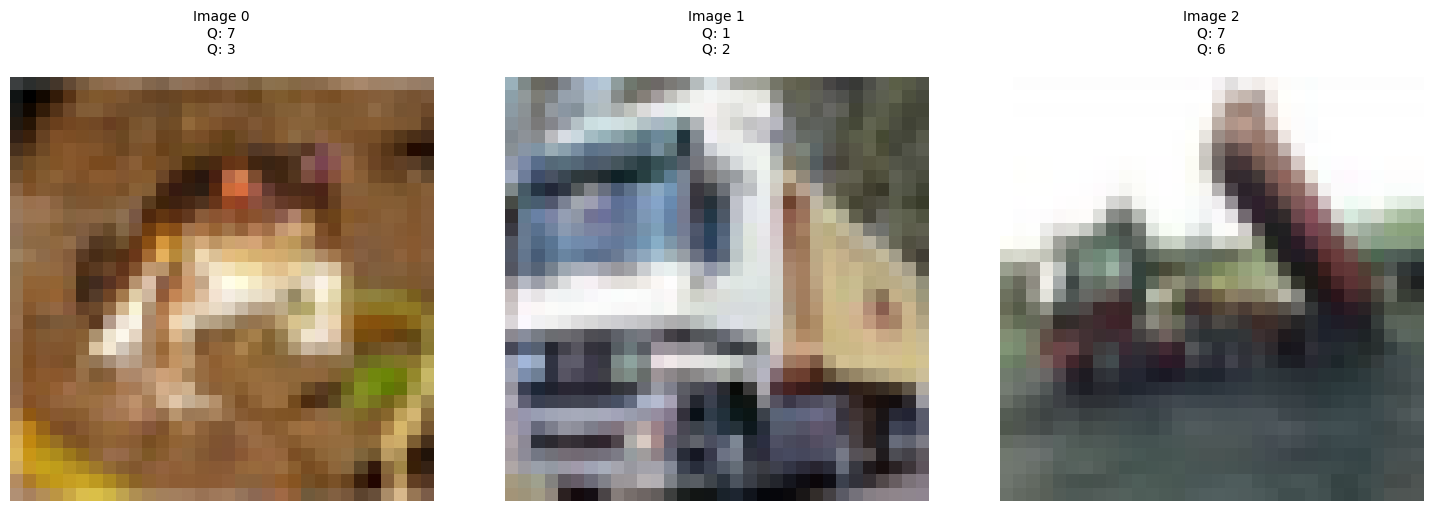

In [13]:
visualize_samples(sample_images, df, n_samples=3)

## 4. Baseline: ResNet + T5

Создадим простой бейз, который:
1. Извлекает эмбеддинги изображений через предобученный ResNet50
2. Извлекает эмбеддинги вопросов через T5-small
3. Объединяет их и предсказывает ответ через MLP

### Задание 4.1: Извлеките эмбеддинги изображений

**Что нужно сделать:**
- Загрузите предобученный ResNet50
- Удалите последний слой классификации (голову)
- Извлеките эмбеддинги для всех изображений

In [14]:
class ImageEncoder:
    def __init__(self):
        # Загружаем предобученный ResNet50
        self.model = models.resnet50(pretrained=True)

        # Удаляем последний FC слой, заменяя его на Identity
        self.model.fc = nn.Identity()

        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def encode(self, images):
        """
        images: список PIL изображений или тензор
        returns: тензор эмбеддингов размера [batch_size, 2048]
        """
        # Преобразуем изображения
        if not isinstance(images, torch.Tensor):
            # Если это список PIL изображений
            transformed = torch.stack([self.transform(img) for img in images])
        else:
            transformed = images

        # Получаем эмбеддинги
        with torch.no_grad():
            embeddings = self.model(transformed)

        return embeddings

image_encoder = ImageEncoder()
image_embeddings = image_encoder.encode(sample_images)  # TODO

print(f"Размерность эмбеддингов изображений: {image_embeddings.shape if image_embeddings is not None else 'Fuck'}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 101MB/s] 


Размерность эмбеддингов изображений: torch.Size([58, 2048])


### Задание 4.2: Извлеките эмбеддинги вопросов

**Что нужно сделать:**
- Загрузите T5-small encoder и tokenizer
- Токенизируйте все вопросы
- Получите эмбеддинги (используйте mean pooling по последней скрытой размерности)

In [15]:
class TextEncoder:
    def __init__(self, model_name='t5-small'):
        # Загружаем токенизатор и encoder модель T5
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5EncoderModel.from_pretrained(model_name)
        self.model.eval()

    def encode(self, texts):
        """
        texts: список строк (вопросов)
        returns: тензор эмбеддингов размера [batch_size, hidden_size]
        """
        # Токенизируем тексты
        encoded = self.tokenizer(
            texts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=512
        )

        # Получаем эмбеддинги от encoder
        with torch.no_grad():
            outputs = self.model(
                input_ids=encoded['input_ids'],
                attention_mask=encoded['attention_mask']
            )

            # Получаем последнее скрытое состояние
            last_hidden_state = outputs.last_hidden_state

            # Mean pooling по последней скрытой размерности (по токенам)
            # Учитываем attention_mask для корректного усреднения
            attention_mask = encoded['attention_mask'].unsqueeze(-1)
            masked_hidden = last_hidden_state * attention_mask
            sum_hidden = masked_hidden.sum(dim=1)
            sum_mask = attention_mask.sum(dim=1)
            embeddings = sum_hidden / sum_mask

        return embeddings

text_encoder = TextEncoder()
question_embeddings = text_encoder.encode(question_bank)
print(f'Размерность эмбеддингов вопросов: {question_embeddings.shape if question_embeddings is not None else ""}')

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Размерность эмбеддингов вопросов: torch.Size([10, 512])


### Задание 4.3: Обучите MLP-классификатор

**Что нужно сделать:**
- Объедините эмбеддинги изображений и вопросов (конкатенация)
- Создайте словарь всех уникальных ответов
- Реализуйте простой MLP (2-3 слоя)
- Обучите модель на нескольких эпохах

**Примечание:** Из-за маленького датасета не ожидайте высокую точность. Цель — понять архитектуру.

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class VQAClassifier(nn.Module):
    def __init__(self, image_dim, text_dim, num_classes, hidden_dim=512):
        super().__init__()

        # Конкатенированная размерность входа
        input_dim = image_dim + text_dim

        # MLP из 3 слоев
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, image_emb, text_emb):
        # Конкатенация эмбеддингов
        combined = torch.cat([image_emb, text_emb], dim=1)
        # Проход через MLP
        logits = self.mlp(combined)
        return logits


# Создание словаря ответов
answer_vocab = {ans: idx for idx, ans in enumerate(df['answer'].unique())}
idx_to_answer = {idx: ans for ans, idx in answer_vocab.items()}
print(f"\nСловарь ответов ({len(answer_vocab)} классов): {list(answer_vocab.keys())}")


# Dataset класс
class VQADataset(Dataset):
    def __init__(self, image_embeddings, text_embeddings, labels):
        self.image_embeddings = image_embeddings
        self.text_embeddings = text_embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.image_embeddings[idx],
            self.text_embeddings[idx],
            self.labels[idx]
        )


# Подготовка данных
# Конвертируем ответы в индексы
labels = torch.tensor([answer_vocab[ans] for ans in df['answer']])

# Создаем датасет и даталоадер
dataset_image_embeddings = [image_embeddings[image_id] for image_id in df['image_id']]
dataset_question_embeddings = [question_embeddings[question_id] for question_id in df['question']]

dataset = VQADataset(dataset_image_embeddings, dataset_question_embeddings, labels)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)


# Инициализация модели
image_dim = 2048  # ResNet50 embedding size
text_dim = 512    # T5-small embedding size
num_classes = len(answer_vocab)

model = VQAClassifier(image_dim, text_dim, num_classes, hidden_dim=512)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model = model.to(device)



Словарь ответов (10 классов): ['лягушка', 'грузовик', 'олень', 'автомобиль', 'птица', 'лошадь', 'корабль', 'кот', 'собака', 'самолет']


In [17]:
dataset_question_embeddings[0].shape

torch.Size([512])

In [18]:
dataset[0][1].shape

torch.Size([512])

In [19]:
model.mlp

Sequential(
  (0): Linear(in_features=2560, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=10, bias=True)
)

In [20]:
# Функция обучения
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for img_emb, txt_emb, labels in dataloader:
        img_emb = img_emb.to(device)
        txt_emb = txt_emb.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(img_emb, txt_emb)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Статистика
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

# Обучение
num_epochs = 10
print("\nНачало обучения:")
for epoch in range(num_epochs):
    loss, acc = train_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Эпоха {epoch+1}/{num_epochs} - Loss: {loss:.4f}, Accuracy: {acc:.2f}%")


# Функция для предсказания
def predict(model, image_embedding, text_embedding):
    model.eval()
    with torch.no_grad():
        img_emb = image_embedding.unsqueeze(0).to(device)
        txt_emb = text_embedding.unsqueeze(0).to(device)
        output = model(img_emb, txt_emb)
        _, predicted = output.max(1)
        answer_idx = predicted.item()
        return idx_to_answer[answer_idx]


# Пример использования
# answer = predict(model, image_embeddings[0], text_embeddings[0])
# print(f"Предсказанный ответ: {answer}")


Начало обучения:
Эпоха 1/10 - Loss: 2.3229, Accuracy: 14.66%
Эпоха 2/10 - Loss: 1.9331, Accuracy: 46.55%
Эпоха 3/10 - Loss: 1.5018, Accuracy: 64.66%
Эпоха 4/10 - Loss: 1.0414, Accuracy: 75.86%
Эпоха 5/10 - Loss: 0.7174, Accuracy: 83.62%
Эпоха 6/10 - Loss: 0.4641, Accuracy: 88.79%
Эпоха 7/10 - Loss: 0.3029, Accuracy: 93.97%
Эпоха 8/10 - Loss: 0.1798, Accuracy: 97.41%
Эпоха 9/10 - Loss: 0.1968, Accuracy: 93.10%
Эпоха 10/10 - Loss: 0.0784, Accuracy: 100.00%


### Задание 4.4: Протестируйте baseline

**Что нужно сделать:**
- Выберите 2-3 примера из датасета
- Получите предсказания модели
- Выведите изображение, вопрос, истинный и предсказанный ответ

ТЕСТИРОВАНИЕ BASELINE МОДЕЛИ

--- Пример 84 ---
Image ID: 41
Вопрос: Что находится на этом снимке?
Истинный ответ: автомобиль


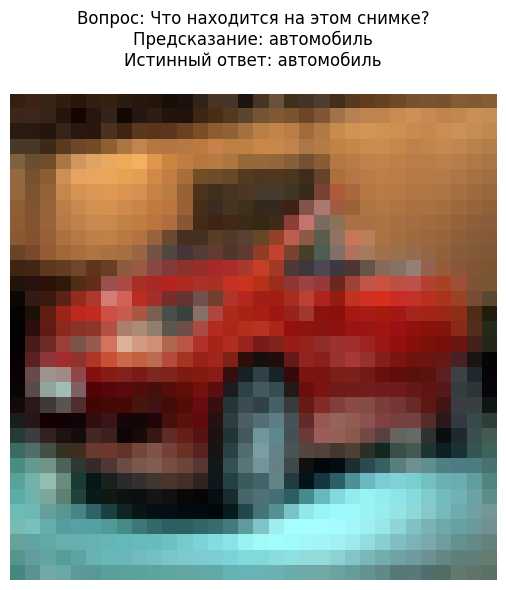

Предсказание: автомобиль
Результат: ✓ ВЕРНО
------------------------------------------------------------

--- Пример 5 ---
Image ID: 2
Вопрос: Кто или что изображён на картинке?
Истинный ответ: грузовик


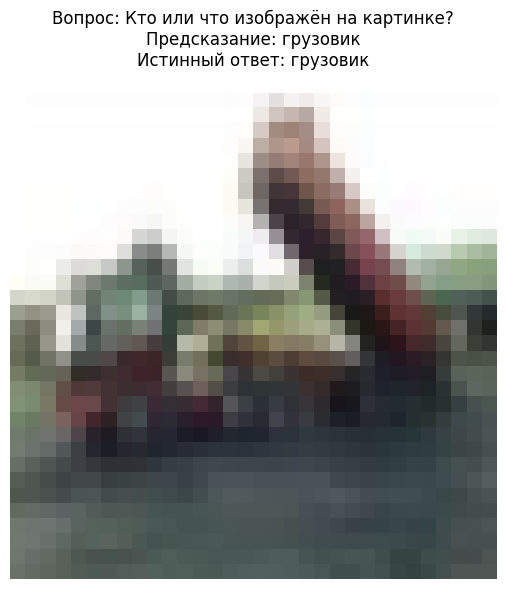

Предсказание: грузовик
Результат: ✓ ВЕРНО
------------------------------------------------------------

--- Пример 43 ---
Image ID: 21
Вопрос: Что показано на этой картинке?
Истинный ответ: кот


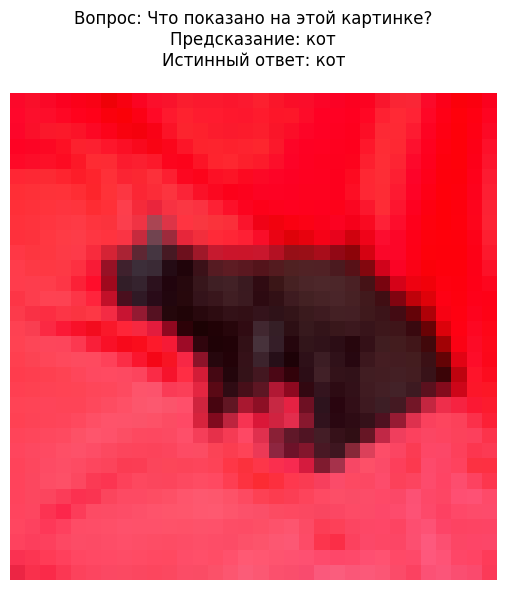

Предсказание: кот
Результат: ✓ ВЕРНО
------------------------------------------------------------


In [21]:
def predict_baseline(image_id, question):
    """
    Предсказывает ответ на вопрос по изображению

    Args:
        image_id: ID изображения из датасета
        question: текст вопроса

    Returns:
        predicted_answer: предсказанный ответ
    """
    # Находим индекс в датасете
    idx = image_id

    # Получаем эмбеддинги
    img_emb = image_embeddings[idx].unsqueeze(0).to(device)

    # Кодируем вопрос
    txt_emb = text_encoder.encode([question]).to(device)

    # Предсказание
    model.eval()
    with torch.no_grad():
        output = model(img_emb, txt_emb)
        _, predicted = output.max(1)
        predicted_answer = idx_to_answer[predicted.item()]

    return predicted_answer


def visualize_prediction(image_id, question, true_answer=None):
    """
    Визуализирует изображение с вопросом и ответами

    Args:
        image_id: ID изображения
        question: текст вопроса
        true_answer: истинный ответ (опционально)
    """
    # Получаем предсказание
    predicted_answer = predict_baseline(image_id, question)

    # Загружаем изображение
    image = sample_images[image_id]

    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis('off')

    # Добавляем текст
    title = f"Вопрос: {question}\n"
    title += f"Предсказание: {predicted_answer}\n"
    if true_answer:
        title += f"Истинный ответ: {true_answer}"

    plt.title(title, fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()

    return predicted_answer


# Тестирование на нескольких примерах
print("=" * 60)
print("ТЕСТИРОВАНИЕ BASELINE МОДЕЛИ")
print("=" * 60)

# Выбираем 3 случайных примера
test_samples = df.sample(n=3, random_state=42)

for idx, row in test_samples.iterrows():
    question_text = question_bank[row['question']]
    print(f"\n--- Пример {idx + 1} ---")
    print(f"Image ID: {row['image_id']}")
    print(f"Вопрос: {question_text}")
    print(f"Истинный ответ: {row['answer']}")

    predicted = visualize_prediction(
        image_id=row['image_id'],
        question=question_text,
        true_answer=row['answer']
    )

    # Проверяем правильность
    is_correct = predicted == row['answer']
    print(f"Предсказание: {predicted}")
    print(f"Результат: {'✓ ВЕРНО' if is_correct else '✗ НЕВЕРНО'}")
    print("-" * 60)


# Альтернатива: тестирование с кастомным вопросом
def test_custom_question(image_id, custom_question):
    """
    Тестирует модель с произвольным вопросом
    """
    print(f"\nКастомный тест:")
    print(f"Image ID: {image_id}")
    print(f"Вопрос: {custom_question}")

    predicted = visualize_prediction(image_id, custom_question)
    print(f"Предсказание: {predicted}")

    return predicted


# Пример использования с кастомным вопросом
# test_custom_question(image_id=df.iloc[0]['image_id'],
#                     custom_question="Что изображено на фотографии?")


## 5. CLIP Zero-Shot Baseline

CLIP — это мультимодальная модель, обученная связывать изображения и тексты. Мы используем её для zero-shot VQA:
1. Для каждой пары (изображение, вопрос) сформируем набор возможных ответов
2. Составим промпты типа "A photo of {answer}"
3. CLIP выберет наиболее вероятный ответ

### Задание 5.1: Загрузите CLIP

**Что нужно сделать:**
- Загрузите CLIP модель (используйте `openai/clip-vit-base-patch32` через transformers)
- Или используйте `open_clip` библиотеку

In [22]:
from transformers import CLIPModel, CLIPProcessor
import torch

# Загрузка модели и процессора
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

# Перевод модели в режим оценки
clip_model.eval()

# Опционально: перенос на GPU
clip_model = clip_model.to(device)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### Задание 5.2: Реализуйте zero-shot VQA с CLIP

**Что нужно сделать:**
- Для каждого изображения и вопроса создайте список возможных ответов (используйте answer_vocab)
- Сформируйте промпты: \"Question: {question}. Answer: {answer}\"
- Используйте CLIP для выбора наиболее подходящего ответа

In [38]:
def predict_clip(image, question, candidate_answers=list(answer_vocab.keys())):
    """
    Предсказание ответа с использованием CLIP для zero-shot VQA.

    Args:
        image: PIL Image
        question: строка с вопросом
        candidate_answers: список возможных ответов

    Returns:
        best_answer: наиболее вероятный ответ
    """
    # 1. Создайте промпты для каждого ответа
    prompts = [f"Question: {question}. Answer: {answer}" for answer in candidate_answers]
    prompts = [f"{answer}" for answer in candidate_answers]

    # 2. Получите эмбеддинги изображения и текстов
    inputs = clip_processor(
        text=prompts,
        images=image,
        return_tensors="pt",
        padding=True
    )

    # Перенос на device (CPU или GPU)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Вычислите косинусное сходство
    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image  # Сходство между изображением и текстами
        probs = logits_per_image.softmax(dim=1)  # Вероятности

    # 4. Верните ответ с максимальным сходством
    best_idx = probs.argmax().item()
    best_answer = candidate_answers[best_idx]

    return best_answer


--- Пример 1 ---
Image ID: 41
Вопрос: Что находится на этом снимке?
Предсказано: автомобиль
Истина: автомобиль
Результат: ✓ Правильно
------------------------------------------------------------
--- Пример 2 ---
Image ID: 2
Вопрос: Кто или что изображён на картинке?
Предсказано: кот
Истина: грузовик
Результат: ✗ Неправильно
------------------------------------------------------------
--- Пример 3 ---
Image ID: 21
Вопрос: Что показано на этой картинке?
Предсказано: кот
Истина: кот
Результат: ✓ Правильно
------------------------------------------------------------
--- Пример 4 ---
Image ID: 20
Вопрос: Что это?
Предсказано: лошадь
Истина: олень
Результат: ✗ Неправильно
------------------------------------------------------------
--- Пример 5 ---
Image ID: 5
Вопрос: Что это?
Предсказано: автомобиль
Истина: автомобиль
Результат: ✓ Правильно
------------------------------------------------------------
--- Пример 6 ---
Image ID: 23
Вопрос: Что можно увидеть на этой фотографии?
Предсказано: ко

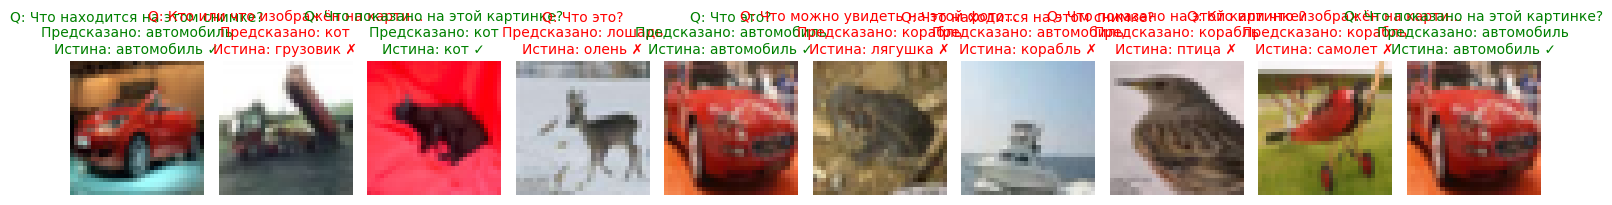


ИТОГОВАЯ СТАТИСТИКА
Правильных ответов: 4/10
Accuracy: 40.00%


In [24]:
def test_clip_with_visualization(num_samples=3):
    """
    Тестирование CLIP на нескольких примерах с визуализацией
    """
    candidate_answers = list(answer_vocab.keys())
    test_samples = df.sample(n=num_samples, random_state=42)

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]

    correct = 0
    total = 0

    for idx, (ax, (_, row)) in enumerate(zip(axes, test_samples.iterrows())):
        # Получение данных
        image = sample_images[row['image_id']]
        question_text = question_bank[row['question']]
        true_answer = row['answer']

        # Предсказание
        predicted = predict_clip(image, question_text, candidate_answers)

        # Визуализация
        ax.imshow(image)
        ax.axis('off')

        # Формирование заголовка
        title = f"Q: {question_text[:30]}...\n" if len(question_text) > 30 else f"Q: {question_text}\n"
        title += f"Предсказано: {predicted}\n"
        title += f"Истина: {true_answer}"

        # Цвет в зависимости от правильности
        is_correct = (predicted == true_answer)
        color = 'green' if is_correct else 'red'
        symbol = " ✓" if is_correct else " ✗"

        ax.set_title(title + symbol, fontsize=10, color=color)

        # Статистика
        if is_correct:
            correct += 1
        total += 1

        print(f"--- Пример {idx + 1} ---")
        print(f"Image ID: {row['image_id']}")
        print(f"Вопрос: {question_text}")
        print(f"Предсказано: {predicted}")
        print(f"Истина: {true_answer}")
        print(f"Результат: {'✓ Правильно' if is_correct else '✗ Неправильно'}")
        print("-" * 60)

    plt.tight_layout()
    plt.show()

    # Итоговая статистика
    accuracy = correct / total * 100
    print(f"\n{'='*60}")
    print(f"ИТОГОВАЯ СТАТИСТИКА")
    print(f"{'='*60}")
    print(f"Правильных ответов: {correct}/{total}")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"{'='*60}")

    return accuracy

# Запуск теста
accuracy = test_clip_with_visualization(num_samples=10)


## 6. LLaVA Inference

LLaVA (Large Language and Vision Assistant) — это большая мультимодальная модель, которая может генерировать текстовые ответы на вопросы об изображениях.

**Внимание:** LLaVA-1.5-7B требует ~14GB GPU памяти. Если в Colab недостаточно памяти, используйте квантизацию (8-bit) или напишите мне про датасферу.

### Задание 6.1: Загрузите LLaVA

**Что нужно сделать:**
- Загрузите модель `llava-hf/llava-1.5-7b-hf`
- При необходимости используйте квантизацию для экономии памяти

In [25]:
import torch
from transformers import BitsAndBytesConfig, LlavaForConditionalGeneration, AutoProcessor

# Ваша конфигурация квантизации (отлично работает!)
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

# Загрузка модели с 4-bit квантизацией
llava_model = LlavaForConditionalGeneration.from_pretrained(
    "llava-hf/llava-1.5-7b-hf",
    quantization_config=quantization_config,
    device_map="auto"
)

# Загрузка процессора (ВАЖНО!)
llava_processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf")


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

### Задание 6.2: Генерация ответов с LLaVA

**Что нужно сделать:**
- Реализуйте функцию для генерации ответов
- Используйте формат промпта: "USER: <image>
Question: {question}
ASSISTANT:"
- Протестируйте на 2-3 примерах

In [26]:
def predict_llava(image, question):
    """
    Генерирует ответ с помощью LLaVA.

    Args:
        image: PIL Image
        question: строка с вопросом

    Returns:
        answer: сгенерированный ответ
    """
    # 1. Формируем промпт
    prompt = f"USER: <image>\nQuestion: {question} Answer in one word from this suit {cifar_classes}, in English:\nASSISTANT:"

    # 2. Подготавливаем входы через processor
    inputs = llava_processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    ).to(llava_model.device)  # Автоматически определяет устройство

    # 3. Генерируем ответ
    with torch.inference_mode():  # Экономит память
        generate_ids = llava_model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False
        )

    # 4. Декодируем результат
    output = llava_processor.batch_decode(
        generate_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    # Извлекаем только ответ
    answer = output.split("ASSISTANT:")[-1].strip()

    return cifar_mapping.get(answer.lower())

    return answer


Пример 1 (Image ID: 0)
Вопрос: Кто или что изображён на картинке?
Истинный ответ: лягушка
LLaVA ответ: птица


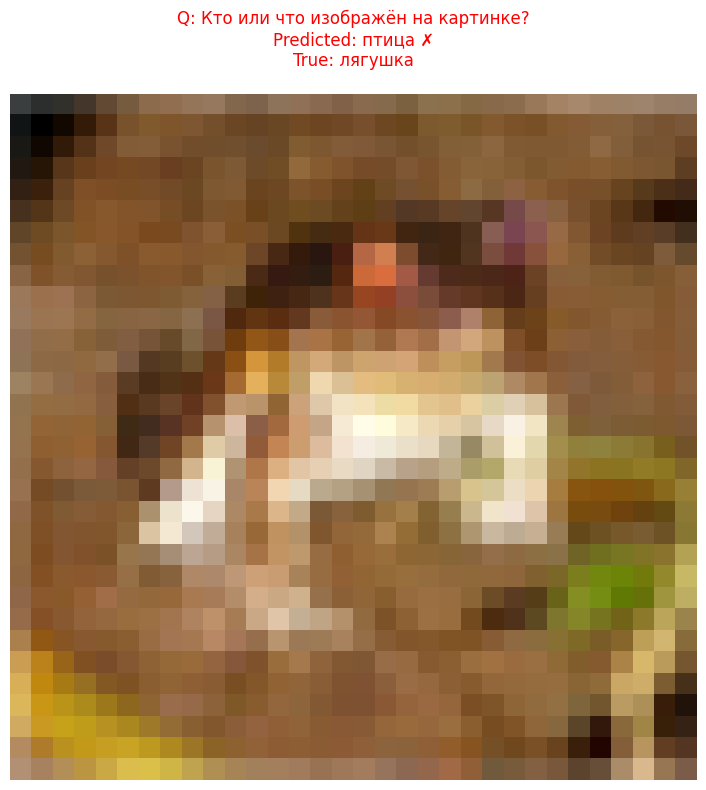


Пример 6 (Image ID: 2)
Вопрос: Что можно увидеть на этой фотографии?
Истинный ответ: грузовик
LLaVA ответ: грузовик


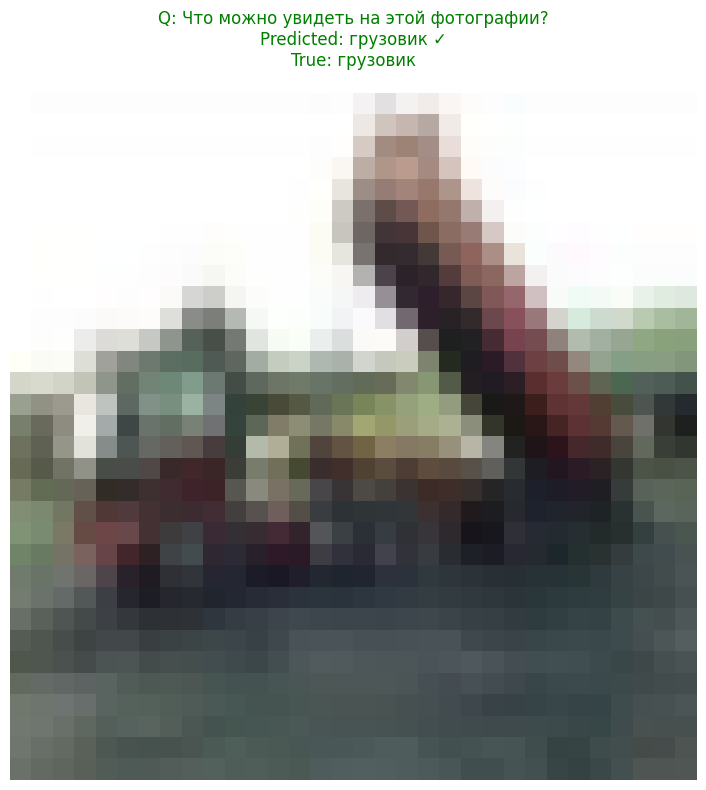


Пример 11 (Image ID: 5)
Вопрос: Что это?
Истинный ответ: автомобиль
LLaVA ответ: автомобиль


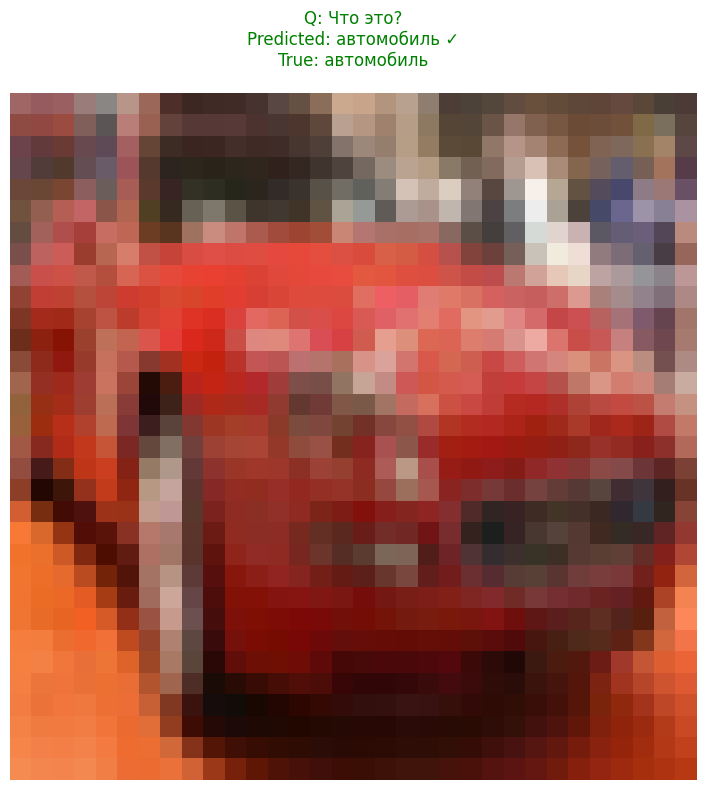

In [27]:
# Тестируем на примерах из вашего датасета с визуализацией
test_samples = [0, 5, 10]

for idx in test_samples:
    image_id = df.iloc[idx]['image_id']
    question = question_bank[df.iloc[idx]['question']]
    true_answer = df.iloc[idx]['answer']

    # Получаем изображение
    image = sample_images[image_id]

    # Предсказание
    predicted_answer = predict_llava(image, question)

    # Вывод результатов
    print(f"\n{'='*60}")
    print(f"Пример {idx + 1} (Image ID: {image_id})")
    print(f"{'='*60}")
    print(f"Вопрос: {question}")
    print(f"Истинный ответ: {true_answer}")
    print(f"LLaVA ответ: {predicted_answer}")

    # Визуализация изображения
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')

    # Проверка правильности
    is_correct = predicted_answer.lower() == true_answer.lower()
    color = 'green' if is_correct else 'red'
    symbol = '✓' if is_correct else '✗'

    # Заголовок с результатами
    title = f"Q: {question}\n"
    title += f"Predicted: {predicted_answer} {symbol}\n"
    title += f"True: {true_answer}"

    plt.title(title, fontsize=12, color=color, pad=20)
    plt.tight_layout()
    plt.show()

## 7. Сравнение результатов

Теперь сравним все три подхода на одних и тех же примерах.

### Задание 7.1: Соберите результаты всех моделей

Что нужно сделать:
- Для каждого примера из датасета получите предсказания от всех трёх моделей
- Создайте сравнительную таблицу
- Проанализируйте, где какая модель работает лучше

In [42]:
import pandas as pd
from tqdm import tqdm

# Инициализация словаря результатов
results = {
    'Image ID': [],
    'Question': [],
    'True Answer': [],
    'ResNet+T5': [],
    'CLIP': [],
    'LLaVA': []
}

print("Генерация предсказаний...")

# Проходим по всему датасету вопросов и ответов
for index, row in tqdm(df.iterrows(), total=len(df)):
    # Получаем изображение по ID
    image_idx = row['image_id']
    image = sample_images[image_idx]
    question_idx = row['question']
    question = question_bank[question_idx]

    # Сохраняем метаданные
    results['Image ID'].append(image_idx)
    results['Question'].append(question)
    results['True Answer'].append(row['answer'])

    # 1. Предсказание Baseline (ResNet + T5)
    # Предполагается, что функция predict_baseline принимает (image, question)
    try:
        res_t5_pred = predict_baseline(image_idx, question)
    except Exception as err:
        print(err)
        res_t5_pred = "error"
    results['ResNet+T5'].append(res_t5_pred)

    # 2. Предсказание CLIP
    # CLIP обычно выбирает из вариантов, здесь предполагаем функцию predict_clip
    try:
        clip_pred = predict_clip(image, question)
    except:
        clip_pred = "error"
    results['CLIP'].append(clip_pred)

    # 3. Предсказание LLaVA
    # Самая тяжелая модель
    try:
        llava_pred = predict_llava(image, question)
    except:
        llava_pred = "error"
    results['LLaVA'].append(llava_pred)

# Создаем DataFrame
results_df = pd.DataFrame(results)

# Показываем случайные 5 строк для проверки
print("\nПримеры результатов:")
display(results_df.sample(5))


Генерация предсказаний...


100%|██████████| 116/116 [01:41<00:00,  1.14it/s]


Примеры результатов:


,Image ID,Question,True Answer,ResNet+T5,CLIP,LLaVA
15,7,Кто или что изображён на картинке?,лошадь,лошадь,птица,лошадь
20,10,Что можно увидеть на этой фотографии?,олень,олень,корабль,олень
44,22,Что вы видите на этом изображении?,лягушка,лягушка,кот,птица
18,9,Что это?,кот,кот,кот,кот
74,37,Какой предмет запечатлён на изображении?,собака,собака,грузовик,собака


### Задание 7.2: Проанализируйте результаты

Что нужно сделать:
- Посчитайте accuracy для каждой модели
- Опишите сильные и слабые стороны каждого подхода
- Приведите примеры, где модели ошибаются или дают разные ответы

In [43]:
def calculate_accuracy(predictions, true_answers):
    correct = 0
    total = len(predictions)

    for pred, true_ans in zip(predictions, true_answers):
        pred_clean = str(pred).lower().strip()
        true_clean = str(true_ans).lower().strip()

        if pred_clean == true_clean or true_clean in pred_clean or pred_clean in true_clean:
            correct += 1

    return correct / total if total > 0 else 0.0

baseline_acc = calculate_accuracy(results_df['ResNet+T5'], results_df['True Answer'])
clip_acc = calculate_accuracy(results_df['CLIP'], results_df['True Answer'])
llava_acc = calculate_accuracy(results_df['LLaVA'], results_df['True Answer'])

print("\nТочность моделей:")
print(f"ResNet+T5: {baseline_acc:.2%}")
print(f"CLIP: {clip_acc:.2%}")
print(f"LLaVA: {llava_acc:.2%}")


Точность моделей:
ResNet+T5: 100.00%
CLIP: 20.69%
LLaVA: 81.90%


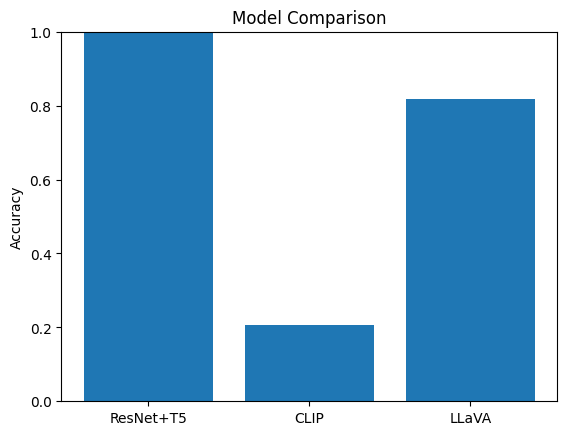

In [44]:
import matplotlib.pyplot as plt
models = ['ResNet+T5', 'CLIP', 'LLaVA']
accuracies = [baseline_acc, clip_acc, llava_acc]
plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])
plt.show()

### Выводы (заполните после экспериментов):

Baseline (ResNet + T5):
- Сильные стороны: Обучено для задачи на наших жанных => самый мощный результат, эффективо работает на конкретном наборе классов
- Слабые стороны: Требует размеченных данных. Плохо генерализуется на новые классы объектов. Ограничена доменом CIFAR-10.

CLIP:
- Сильные стороны: Не требует обучения на конкретной задаче. Может работать с произвольными изображениями и текстовыми описаниями благодаря обучению на больших мультимодальных датасетах. Быстрая инференция через простое вычисление косинусного сходства.

- Слабые стороны: Показала худший результат (25.86% accuracy) среди всех моделей. Не предназначена для VQA - работает только на уровне сопоставления эмбеддингов без глубокого понимания вопроса. Отсутствует reasoning. Простое косинусное сходство недостаточно для сложных вопросов, требующих анализа контекста. Не может генерировать ответы, только выбирает из предложенных вариантов.

LLaVA:
- Сильные стороны: Показала хороший результат (81.90% accuracy) в zero-shot режиме без обучения на данных. Объединяет vision encoder и большую языковую модель, что дает способности к рассуждению. Может генерировать развернутые текстовые ответы, а не только выбирать из вариантов. Хорошо понимает контекст вопросов благодаря LLM-компоненту. Универсальная и может работать с различными типами изображений и вопросов.

- Слабые стороны: Требует значительные вычислительные ресурсы для инференса. Медленнее работает по сравнению с CLIP и baseline. Может генерировать избыточные или неточные ответы без строгого контроля формата. Зависит от качества промпта и формулировки вопроса.

**Общие наблюдения**:
* Для production-систем с фиксированным набором классов оптимален подход с обучением специализированной модели (ResNet+T5)
​
* Для универсальных приложений с разнообразными вопросами лучше выбрать LLaVA, несмотря на больше ресурсозатраты
​
* CLIP не подходит для VQA-задач, но эффективна для image-text matching и классификации
​
* Важность архитектуры: модели с языковыми компонентами (T5, LLM) значительно лучше понимают вопросы, чем простое эмбеддинг-сопоставление

Мнения о домашке: Прикольная домашка, видно что происходит, объединение доменов зрелищно, появляется понимение того что можно запустить имея те или иные вычислительные ресурсы